# QUI EMPRUNTE QUOI ?

## Feuille de route
* Gros emprunteurs ou petits emprunteurs ?
* Emprunteurs réguliers ou emprunteurs ponctuels ?
* Quel usage des collections par âge ? (les + et les - empruntées, filtre 10 ccodes)
* Courbe de Lawrance : concentration des prêts

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import datetime

from kiblib.utils.db import DbConn
from kiblib.utils import lucas_sns_params

In [2]:
query = "SELECT * FROM statdb.stat_issues WHERE YEAR(issuedate)='2025'"

In [3]:
db_conn = DbConn().create_engine()
issues = pd.read_sql(query,con=db_conn)

In [4]:
issues['année'] = pd.DatetimeIndex(issues['issuedate']).year

In [5]:
issues['nb'] = 1

In [6]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,publicationyear,biblionumber,dateaccessioned,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2024,370947.0,2024-12-07,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,2024,368381.0,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,1,2025,1
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2020,332180.0,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2024,369018.0,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2009,278063.0,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302746,2025-11-09 16:08:00,2025-11-30 23:59:00,2025-11-09 16:33:13,0,MED,None,75199,X0002761794,12,M,...,2017,303377.0,2018-01-06,2025-11-09 16:08:00-370843,2025-11-11 03:12:02,5620821,None,1,2025,1
302747,2025-11-09 16:09:22,2025-11-30 23:59:00,2025-11-09 16:20:50,0,MED,None,87609,X0002849300,20,F,...,2008,203228.0,2009-01-03,2025-11-09 16:09:22-231869,2025-11-11 03:12:02,5620822,None,1,2025,1
302748,2025-11-09 17:03:11,2025-11-30 23:59:00,2025-11-09 17:28:38,0,MED,None,53752,X0002452135,46,F,...,1980,154629.0,2025-08-23,2025-11-09 17:03:11-497510,2025-11-11 03:12:02,5620823,None,1,2025,1
302749,2025-11-09 17:30:01,2025-11-30 23:59:00,2025-11-09 17:40:30,0,MED,None,60753,X0002489971,43,M,...,2024,375031.0,2025-06-19,2025-11-09 17:30:01-495382,2025-11-11 03:12:02,5620824,None,1,2025,1


In [7]:
# 2 méthodes pour faire la même chose

#Avec transform
issues['nb docs empruntés pour cet emprunteur'] = issues.groupby('borrowernumber')['borrowernumber'].transform('count')


# Avec map + valuecounts()
issues['nb docs empruntés pour cet emprunteur 2'] = issues['borrowernumber'].map(issues['borrowernumber'].value_counts())

In [8]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,dateaccessioned,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2024-12-07,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1,40,40
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,1,2025,1,40,40
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1,185,185
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1,139,139
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1,83,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302746,2025-11-09 16:08:00,2025-11-30 23:59:00,2025-11-09 16:33:13,0,MED,None,75199,X0002761794,12,M,...,2018-01-06,2025-11-09 16:08:00-370843,2025-11-11 03:12:02,5620821,None,1,2025,1,41,41
302747,2025-11-09 16:09:22,2025-11-30 23:59:00,2025-11-09 16:20:50,0,MED,None,87609,X0002849300,20,F,...,2009-01-03,2025-11-09 16:09:22-231869,2025-11-11 03:12:02,5620822,None,1,2025,1,11,11
302748,2025-11-09 17:03:11,2025-11-30 23:59:00,2025-11-09 17:28:38,0,MED,None,53752,X0002452135,46,F,...,2025-08-23,2025-11-09 17:03:11-497510,2025-11-11 03:12:02,5620823,None,1,2025,1,88,88
302749,2025-11-09 17:30:01,2025-11-30 23:59:00,2025-11-09 17:40:30,0,MED,None,60753,X0002489971,43,M,...,2025-06-19,2025-11-09 17:30:01-495382,2025-11-11 03:12:02,5620824,None,1,2025,1,226,226


In [9]:
issues['nb personnes ayant emprunté ce nombre de livre en 2025'] = issues['nb docs empruntés pour cet emprunteur'].map(issues['nb docs empruntés pour cet emprunteur'].value_counts())

In [10]:
issues_dist = issues.drop_duplicates(subset=['borrowernumber'],keep='first')

In [11]:
issues_dist

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2,nb personnes ayant emprunté ce nombre de livre en 2025
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1,40,40,2840
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1,185,185,740
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1,139,139,1112
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1,83,83,1162
6,2025-01-02 09:45:47,2025-01-23 23:59:00,2025-01-09 15:36:31,0,MED,None,9572,X0002555904,76,M,...,2025-01-02 09:45:47-383954,2025-01-10 03:13:54,5190420,None,1,2025,1,10,10,4280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302564,2025-11-09 17:21:33,2025-11-30 23:59:00,NaT,0,MED,None,88528,X0002870960,66,M,...,2025-11-09 17:21:33-290845,2025-11-11 03:12:02,5620619,None,1,2025,1,3,3,1938
302574,2025-11-09 17:22:48,2025-11-30 23:59:00,NaT,0,MED,None,69080,X0002589978,50,F,...,2025-11-09 17:22:48-496450,2025-11-11 03:12:02,5620629,None,1,2025,1,2,2,1534
302693,2025-11-09 17:42:54,2025-11-30 23:59:00,NaT,0,MED,None,87763,X0002850221,8,M,...,2025-11-09 17:42:54-486614,2025-11-11 03:12:02,5620748,None,1,2025,1,1,1,918
302701,2025-11-09 17:49:07,2025-11-30 23:59:00,NaT,0,MED,None,77755,X0002696492,36,F,...,2025-11-09 17:49:07-473445,2025-11-11 03:12:02,5620756,None,1,2025,1,10,10,4280


In [12]:
issues_dist = issues_dist.groupby('nb docs empruntés pour cet emprunteur')['nb personnes ayant emprunté ce nombre de livre en 2025'].size().to_frame().reset_index()

In [13]:
issues_dist['volume docs empruntés'] = issues_dist['nb docs empruntés pour cet emprunteur'] * issues_dist['nb personnes ayant emprunté ce nombre de livre en 2025']

In [14]:
issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=1)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=10),
                'nb docs empruntés label'
               ] = 'a/ Entre 1 et 10 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=11)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=20),
                'nb docs empruntés label',
               ] = 'b/ Entre 11 et 20 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=21)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=40),
                'nb docs empruntés label',
               ] = 'c/ Entre 21 et 40 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=41)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=60),
                'nb docs empruntés label',
               ] = 'd/ Entre 41 et 60 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=61)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=80),
                'nb docs empruntés label',
               ] = 'e/ Entre 61 et 80 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=81)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=100),
                'nb docs empruntés label',
               ] = 'f/ Entre 81 et 100 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=101)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=120),
                'nb docs empruntés label',
               ] = 'g/ Entre 101 et 120 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=121)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=140),
                'nb docs empruntés label',
               ] = 'h/ Entre 121 et 140 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=141)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=160),
                'nb docs empruntés label',
               ] = 'i/ Entre 141 et 160 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=161)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=180),
                'nb docs empruntés label',
               ] = 'j/ Entre 161 et 180 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=181)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=200),
                'nb docs empruntés label',
               ] = 'k/ Entre 181 et 200 \ndocs empruntés'


issues_dist.loc[issues_dist['nb docs empruntés pour cet emprunteur']>=200,
                'nb docs empruntés label',
               ] = 'x/ Plus de 200 \ndocs empruntés'

In [16]:
# Comment automatiser la création des labels au-dessus ↑
nmin = 1
nmax=10
for i in range(1,21):
    print(f"tour n°{i}")
    print("° "*10)
    print(f"x/ Entre {nmin} et {nmax} docs empruntés sur la période")
    print(" ")
    
    # Ajout d'un label "test" contenant l'interval de docs empruntés
    
    issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=nmin)&
                    (issues_dist['nb docs empruntés pour cet emprunteur']<=nmax),
                    'test label boucle période'
                   ] = f'{i}/ Entre {nmin} et {nmax} docs empruntés sur la période'
    
    nmin+= 10
    nmax+= 10
    chapter+=1
    

tour n°1
° ° ° ° ° ° ° ° ° ° 
x/ Entre 1 et 10 docs empruntés sur la période
 


NameError: name 'chapter' is not defined

In [17]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label,test label boucle période
0,1,918,918,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
1,2,767,1534,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
2,3,646,1938,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
3,4,558,2232,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
4,5,445,2225,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
...,...,...,...,...,...
279,582,1,582,x/ Plus de 200 \ndocs empruntés,NaN
280,613,1,613,x/ Plus de 200 \ndocs empruntés,NaN
281,639,1,639,x/ Plus de 200 \ndocs empruntés,NaN
282,676,1,676,x/ Plus de 200 \ndocs empruntés,NaN


In [18]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label,test label boucle période
0,1,918,918,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
1,2,767,1534,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
2,3,646,1938,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
3,4,558,2232,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
4,5,445,2225,a/ Entre 1 et 10 \ndocs empruntés,1/ Entre 1 et 10 docs empruntés sur la période
...,...,...,...,...,...
279,582,1,582,x/ Plus de 200 \ndocs empruntés,NaN
280,613,1,613,x/ Plus de 200 \ndocs empruntés,NaN
281,639,1,639,x/ Plus de 200 \ndocs empruntés,NaN
282,676,1,676,x/ Plus de 200 \ndocs empruntés,NaN


In [19]:
issues_dist_2 = issues_dist.pivot_table(index='nb docs empruntés label',
                                       values=['nb personnes ayant emprunté ce nombre de livre en 2025',
                                               'volume docs empruntés'],
                                       aggfunc=sum
                                      )

In [20]:
issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'] / issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'].sum()*100

In [21]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,
a/ Entre 1 et 10 \ndocs empruntés,5181,23515,47.972222
b/ Entre 11 et 20 \ndocs empruntés,1788,27191,16.555556
c/ Entre 21 et 40 \ndocs empruntés,1662,48644,15.388889
d/ Entre 41 et 60 \ndocs empruntés,792,39376,7.333333
e/ Entre 61 et 80 \ndocs empruntés,482,33585,4.462963
f/ Entre 81 et 100 \ndocs empruntés,279,25094,2.583333
g/ Entre 101 et 120 \ndocs empruntés,190,20860,1.759259
h/ Entre 121 et 140 \ndocs empruntés,118,15376,1.092593
i/ Entre 141 et 160 \ndocs empruntés,83,12403,0.768519


In [22]:
issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'].cumsum()

In [23]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025,% cumulé personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,,
a/ Entre 1 et 10 \ndocs empruntés,5181,23515,47.972222,47.972222
b/ Entre 11 et 20 \ndocs empruntés,1788,27191,16.555556,64.527778
c/ Entre 21 et 40 \ndocs empruntés,1662,48644,15.388889,79.916667
d/ Entre 41 et 60 \ndocs empruntés,792,39376,7.333333,87.250000
e/ Entre 61 et 80 \ndocs empruntés,482,33585,4.462963,91.712963
f/ Entre 81 et 100 \ndocs empruntés,279,25094,2.583333,94.296296
g/ Entre 101 et 120 \ndocs empruntés,190,20860,1.759259,96.055556
h/ Entre 121 et 140 \ndocs empruntés,118,15376,1.092593,97.148148
i/ Entre 141 et 160 \ndocs empruntés,83,12403,0.768519,97.916667


In [24]:
issues_dist_2.columns

Index(['nb personnes ayant emprunté ce nombre de livre en 2025',
       'volume docs empruntés',
       '% personnes ayant emprunté ce nombre de docs en 2025',
       '% cumulé personnes ayant emprunté ce nombre de docs en 2025'],
      dtype='object')

In [25]:
issues_dist_2["% cumulé personnes ayant emprunté ce nombre de docs en 2025"]

nb docs empruntés label
a/ Entre 1 et 10 \ndocs empruntés        47.972222
b/ Entre 11 et 20 \ndocs empruntés       64.527778
c/ Entre 21 et 40 \ndocs empruntés       79.916667
d/ Entre 41 et 60 \ndocs empruntés       87.250000
e/ Entre 61 et 80 \ndocs empruntés       91.712963
f/ Entre 81 et 100 \ndocs empruntés      94.296296
g/ Entre 101 et 120 \ndocs empruntés     96.055556
h/ Entre 121 et 140 \ndocs empruntés     97.148148
i/ Entre 141 et 160 \ndocs empruntés     97.916667
j/ Entre 161 et 180 \ndocs empruntés     98.388889
k/ Entre 181 et 200 \ndocs empruntés     98.740741
x/ Plus de 200 \ndocs empruntés         100.000000
Name: % cumulé personnes ayant emprunté ce nombre de docs en 2025, dtype: float64

> NOTE : le graphique ci-dessous se li de gauche à droite, les chiffres sont cumulés.  

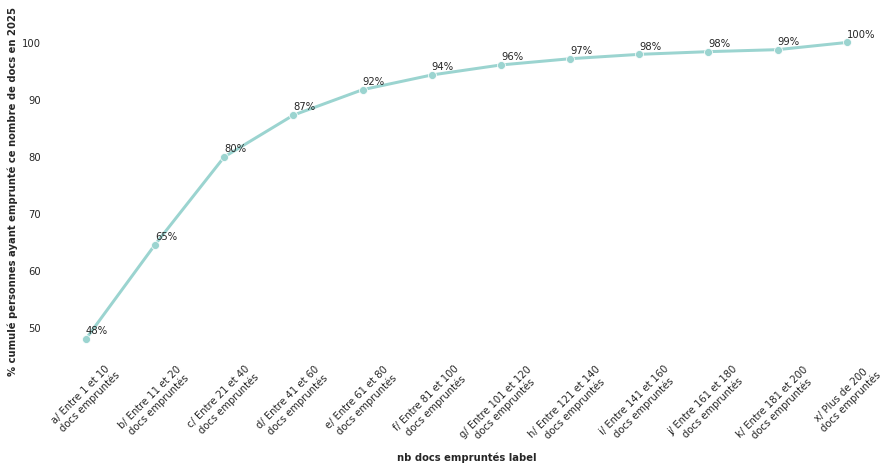

In [26]:
f,ax = plt.subplots(nrows=1,ncols=1)

ax = sns.lineplot(data=issues_dist_2,
             x=issues_dist_2.index,
             y='% cumulé personnes ayant emprunté ce nombre de docs en 2025',
             #ax=ax[1],
             marker='o',
           )

for x,y in zip(issues_dist_2.index,issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025']):
    plt.text(x=x,y=y+1,s = '{:.0f}'.format(y) + '%')

ax.tick_params(axis='x',rotation=45)